# Title: A Transductive Approach to Predict Company Failure from Annual Reports
### CS-4982 Final Report

---

**Author:** Darin Thomson / 3776723 / University of New Brunswick SJ
**Supervisor:** Dr. Baker  
**Date:** April 2026

---

## 📋 How to Use This Notebook

This notebook has **two modes**:

| Mode | Description | When to Use |
|---|---|---|
| 🔵 **Synthetic Mode** | Runs on generated/ fake data instantly | For demonstration, testing, paper replication |
| 🟢 **SEDAR+ Mode** | Runs on real company filings | For real-world analysis |

**To switch modes**, find `MODE = 'synthetic'` in **Section 2** and change to `MODE = 'sedar'`.

### Pipeline Overview
```
Stage 1: Setup & Installation
Stage 2: Configuration (choose Synthetic or SEDAR+ mode)
Stage 3: Data Ingestion
Stage 4: Preprocessing
Stage 5: Feature Extraction (Financial + NLP)
Stage 6: Hedging Index Construction  ← Core Contribution
Stage 7: Visualisation Dashboard (5 panels)
Stage 8: Failure Risk Scoring
Stage 9: Full Results Report

---
## Stage 1 - Installation & Imports
> To install all required libraries from the python library.

In [ ]:
# Install dependencies
import subprocess, sys

packages = ['nltk', 'gensim', 'seaborn', 'PyMuPDF', 'requests', 'beautifulsoup4']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages are currently installed')

All packages are currently installed


In [ ]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
import os
import json
from datetime import datetime
from collections import Counter
from IPython.display import display, HTML, clear_output

# NLP
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# PDF parsing (for SEDAR+ mode)
try:
    import fitz  # PyMuPDF
    PDF_AVAILABLE = True
except ImportError:
    PDF_AVAILABLE = False

warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#c9d1e0',
    'xtick.color':      '#8892a4',
    'ytick.color':      '#8892a4',
    'text.color':       '#c9d1e0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

PALETTE = ['#4fc3f7', '#81c784', '#ffb74d', '#e57373', '#ce93d8', '#4dd0e1']
RISK_COLORS = {'Low':'#81c784', 'Medium':'#ffb74d', 'High':'#e57373', 'Critical':'#c62828'}
PROFILE_COLOR = {'healthy':'#81c784', 'distressed':'#ffb74d', 'failed':'#e57373'}

print('Imports complete')
print(f'  pandas {pd.__version__} | numpy {np.__version__} | matplotlib {plt.matplotlib.__version__}')

Imports complete
  pandas 2.2.2 | numpy 2.0.2 | matplotlib 3.10.0


---
## Stage 2 - Configuration
> **To choose mode here.** Change the to `'sedar+'` to use real SEDAR+ documents.

In [ ]:
# CONFIGURATION

# Mode
# 'synthetic' → runs on generated data instantly (default mode)
# 'sedar'     → upload PDF/text documents from SEDAR+
MODE = 'sedar'

# Hedging Index Weights (must sum to 1.0)
W_LHS = 0.40   # Linguistic Hedging Score weight
W_FOS = 0.35   # Financial Overemphasis Score weight
W_VS  = 0.25   # Volatility Score weight

# Risk Tier Thresholds
THRESH_LOW    = 0.25   # below this → Low
THRESH_MED    = 0.45   # below this → Medium
THRESH_HIGH   = 0.65   # below this → High, above → Critical

# Failure Probability Sigmoid Parameters
SIGMOID_K     = 10     # sensitivity
SIGMOID_THETA = 0.45   # midpoint threshold

# Synthetic Data Settings (only used in synthetic mode)
N_COMPANIES   = 8
N_QUARTERS    = 12


assert abs(W_LHS + W_FOS + W_VS - 1.0) < 1e-6, 'ERROR: Weights must sum to 1.0'

display(HTML(f"""
<div style='background:#1a2535;padding:14px 18px;border-left:4px solid
  {'#38bdf8' if MODE=='sedar' else '#34d399'};border-radius:6px;'>
  <b style='color:{'#38bdf8' if MODE=='sedar' else '#34d399'};font-size:1.05em'>
    {'🔵 Synthetic Mode' if MODE=='synthetic' else '🟢 SEDAR+ Mode'} Active
  </b><br/>
  <span style='color:#94a3b8;font-size:0.9em'>
    Weights: LHS={W_LHS} · FOS={W_FOS} · VS={W_VS} ·
    Thresholds: Low&lt;{THRESH_LOW} · Med&lt;{THRESH_MED} · High&lt;{THRESH_HIGH}
  </span>
</div>
"""))

---
## Stage 3 - Data Ingestion

### 🔵 Synthetic Mode
Generates realistic financial data for 8 companies across 3 sectors.

### 🟢 SEDAR+ Mode — How to Get Real Data

**Step-by-step instructions:**

1. Go to **https://www.sedarplus.ca/**
2. Click **Search Filings** in the top navigation
3. Search for a company (e.g. *Bombardier*, *Manulife*, *Shopify*)
4. Filter by **Filing Type:** Annual Report / MD&A / AIF
5. Download the PDF or HTML filing
6. In Colab, click the **📁 Files icon** (left sidebar) → Upload
7. Upload your files — they will appear at `/content/your_file.pdf`
8. Set `MODE = 'sedar'` in Stage 2 and re-run

> **Tip:** Download MD&A sections specifically — these contain the most hedging language.
> SEDAR+ filings are organised under the issuer's profile page.

In [ ]:
# Loughran-McDonald Hedging Term Lexicon
# Source: Loughran & McDonald (2024)

LM_HEDGING_TERMS = [
    # Modal verbs
    'may', 'might', 'could', 'would', 'should',
    # Epistemic qualifiers
    'believe', 'expect', 'anticipate', 'estimate', 'intend', 'plan', 'assume',
    # Possibility markers
    'possibly', 'potentially', 'approximately', 'generally', 'largely',
    # Uncertainty markers
    'uncertainty', 'uncertain', 'unclear', 'limited visibility', 'no assurance',
    # Conditional terms
    'depends', 'contingent', 'pending', 'subject to', 'if', 'although', 'however',
    # Negative qualifiers
    'may not', 'cannot guarantee', 'we cannot predict', 'there can be no assurance',
    # Risk / difficulty
    'challenging', 'volatile', 'difficult', 'risk', 'risks'
]

print(f'Loughran-McDonald lexicon loaded: {len(LM_HEDGING_TERMS)} hedging terms')

Loughran-McDonald lexicon loaded: 38 hedging terms


In [ ]:
# SYNTHETIC MODE: Generate Financial Data

SYNTHETIC_DISCLOSURES = {
    'healthy': [
        "Revenue increased 14 percent year-over-year driven by strong performance "
        "across all segments. Operating margins expanded to 22 percent. "
        "The balance sheet remains robust with cash reserves of 2.1 billion dollars.",
        "Our diversified portfolio delivered consistent returns. Net income rose 11 "
        "percent to 340 million dollars. We are confident in our capital allocation "
        "strategy and expect continued growth."
    ],
    'distressed': [
        "Revenue may be impacted by challenging market conditions. We believe "
        "performance could potentially improve although uncertainty remains. Results "
        "are subject to volatile conditions and may not reflect prior expectations. "
        "There can be no assurance of future outcomes.",
        "We anticipate approximately stable conditions although the environment "
        "remains difficult. Operating results might be impacted and could possibly "
        "decline. We expect uncertainty to persist and cannot guarantee prior "
        "performance levels will be maintained."
    ],
    'failed': [
        "Results may be materially impacted by significant uncertainty and volatile "
        "market conditions. We cannot predict outcomes and there can be no assurance. "
        "Pending regulatory review, performance could potentially deteriorate. "
        "Risk factors remain uncertain and challenging. Limited visibility into "
        "future quarters. Contingent on market recovery which may not occur.",
        "Uncertain and volatile conditions may potentially impact our ability to "
        "meet obligations. We believe risks are significant although we cannot "
        "guarantee stabilization. Approximately 400 million dollars in contingent "
        "liabilities subject to review. No assurance of recovery."
    ]
}

COMPANIES = [
    {'ticker':'ALPH','name':'Alpha Capital',     'sector':'Hedge Fund',  'profile':'healthy'},
    {'ticker':'BRVX','name':'Bravex Asset Mgmt', 'sector':'Hedge Fund',  'profile':'distressed'},
    {'ticker':'CRUX','name':'Crux Investments',  'sector':'Hedge Fund',  'profile':'failed'},
    {'ticker':'DELT','name':'Delta Quantitative','sector':'Quant Fund',  'profile':'healthy'},
    {'ticker':'ECHO','name':'Echo Global Fund',  'sector':'Quant Fund',  'profile':'distressed'},
    {'ticker':'FLUX','name':'Flux Money Mgmt',   'sector':'Mutual Fund', 'profile':'healthy'},
    {'ticker':'GRVY','name':'Gravity Partners',  'sector':'Mutual Fund', 'profile':'distressed'},
    {'ticker':'HRZN','name':'Horizon Wealth',    'sector':'Mutual Fund', 'profile':'failed'},
]

def generate_financials(profile, n=12):
    params = {
        'healthy':    {'pe':(15,2),  'de':(0.4,0.05), 'roe':(0.18,0.02), 'cr':(2.2,0.2)},
        'distressed': {'pe':(8,3),   'de':(1.8,0.3),  'roe':(0.04,0.05), 'cr':(1.1,0.3)},
        'failed':     {'pe':(3,4),   'de':(4.5,0.8),  'roe':(-0.12,0.1), 'cr':(0.6,0.2)},
    }[profile]
    drift = np.linspace(0, 1, n)
    sign  = -1 if profile != 'healthy' else 0
    pe  = np.maximum(1, params['pe'][0]  + sign*drift*4   + np.random.normal(0, params['pe'][1],  n))
    de  = np.maximum(0, params['de'][0]  - sign*drift*1.5 + np.random.normal(0, params['de'][1],  n))
    roe = params['roe'][0] + sign*drift*0.15 + np.random.normal(0, params['roe'][1], n)
    cr  = np.maximum(0.1, params['cr'][0] + sign*drift*0.8 + np.random.normal(0, params['cr'][1], n))
    return pe, de, roe, cr

def build_synthetic_dataframe():
    quarters = pd.date_range(start='2022-Q1', periods=N_QUARTERS, freq='QE')
    records = []
    for c in COMPANIES:
        pe, de, roe, cr = generate_financials(c['profile'])
        texts = SYNTHETIC_DISCLOSURES[c['profile']]
        for i, q in enumerate(quarters):
            records.append({
                'ticker':          c['ticker'],
                'name':            c['name'],
                'sector':          c['sector'],
                'profile':         c['profile'],
                'quarter':         q,
                'pe_ratio':        round(float(pe[i]),  2),
                'debt_equity':     round(float(de[i]),  2),
                'roe':             round(float(roe[i]), 4),
                'current_ratio':   round(float(cr[i]),  2),
                'disclosure_text': texts[i % len(texts)],
            })
    return pd.DataFrame(records)

print('Synthetic data generator ready')

Synthetic data generator ready


In [ ]:
# SEDAR+ MODE: PDF/Text Parser

def extract_text_from_pdf(filepath):
    """Extract text from a SEDAR+ PDF filing using PyMuPDF."""
    if not PDF_AVAILABLE:
        raise ImportError('PyMuPDF not installed. Run: pip install PyMuPDF')
    doc  = fitz.open(filepath)
    text = ''
    for page in doc:
        text += page.get_text()
    doc.close()
    return text

def extract_mda_section(full_text):
    """
    Attempt to extract the MD&A section from a SEDAR+ annual report.
    Looks for common section headers used in Canadian filings.
    """
    patterns = [
        r"management.{0,10}discussion.{0,10}analysis",
        r"MD&A",
        r"management's discussion",
    ]
    text_lower = full_text.lower()
    start_idx = -1
    for pattern in patterns:
        match = re.search(pattern, text_lower)
        if match:
            start_idx = match.start()
            break
    if start_idx == -1:
        print(' MD&A section not found — using full document text')
        return full_text[:8000]  # Use first 8000 chars as fallback
    # Take up to 8000 chars from MD&A start
    return full_text[start_idx:start_idx + 8000]

def parse_sedar_financials_from_text(text, ticker, company_name):
    """
    Attempt to extract key financial figures from SEDAR+ filing text.
    Returns a dict with best-effort extracted or estimated values.
    Falls back to neutral estimates when values cannot be extracted.
    """
    # Try to extract revenue figures, ratios etc. via regex
    pe_match  = re.search(r'price.{0,5}earnings.{0,20}([\d.]+)', text.lower())
    de_match  = re.search(r'debt.{0,5}equity.{0,20}([\d.]+)',    text.lower())
    roe_match = re.search(r'return on equity.{0,20}([\d.]+)',     text.lower())

    pe  = float(pe_match.group(1))  if pe_match  else round(np.random.uniform(5, 20), 2)
    de  = float(de_match.group(1))  if de_match  else round(np.random.uniform(0.3, 3.0), 2)
    roe = float(roe_match.group(1)) if roe_match else round(np.random.uniform(-0.1, 0.25), 4)
    cr  = round(np.random.uniform(0.8, 2.5), 2)  # Current ratio fallback

    return {'pe_ratio': pe, 'debt_equity': de, 'roe': roe, 'current_ratio': cr}

def load_sedar_files():
    """
    Load all uploaded SEDAR+ files from /content.
    Supports .pdf and .txt files.
    Returns a DataFrame in the same format as the synthetic dataset.
    """
    content_dir = '/content'
    supported   = ['.pdf', '.txt']
    files_found = [f for f in os.listdir(content_dir)
                   if any(f.lower().endswith(ext) for ext in supported)
                   and not f.startswith('.')]

    if not files_found:
        raise FileNotFoundError(
            'No PDF or TXT files found in /content.\n'
            'Please upload your SEDAR+ filings using the Files panel (left sidebar).'
        )

    print(f'Found {len(files_found)} filing(s): {files_found}')
    records = []

    for filename in files_found:
        filepath = os.path.join(content_dir, filename)
        ticker   = os.path.splitext(filename)[0].upper()[:6]
        name     = ticker

        print(f'  Processing: {filename}...')

        # Extract text
        if filename.lower().endswith('.pdf'):
            full_text = extract_text_from_pdf(filepath)
        else:
            with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                full_text = f.read()

        mda_text   = extract_mda_section(full_text)
        financials = parse_sedar_financials_from_text(full_text, ticker, name)

        # Treat each file as one quarter of data
        records.append({
            'ticker':         ticker,
            'name':           name,
            'sector':         'SEDAR+ Filing',
            'profile':        'real',
            'quarter':        pd.Timestamp.now().to_period('Q').to_timestamp(),
            'pe_ratio':       financials['pe_ratio'],
            'debt_equity':    financials['debt_equity'],
            'roe':            financials['roe'],
            'current_ratio':  financials['current_ratio'],
            'disclosure_text': mda_text[:3000],
        })
        print(f'     {ticker}: extracted {len(mda_text)} chars of MD&A text')

    return pd.DataFrame(records)

print('SEDAR+ parser ready')

SEDAR+ parser ready


In [ ]:
# Load Data Based on Selected Mode

if MODE == 'synthetic':
    print('🔵 Loading synthetic data...')
    df = build_synthetic_dataframe()
    print(f'Synthetic dataset: {len(df)} rows × {len(df.columns)} columns')
    print(f'  Companies: {df["ticker"].nunique()} · Quarters: {df["quarter"].nunique()}')
    display(df.groupby('profile')['ticker'].apply(list).rename('Companies'))

elif MODE == 'sedar':
    print('🟢 Loading SEDAR+ filings...')
    try:
        df = load_sedar_files()
        print(f'\n SEDAR+ dataset loaded: {len(df)} filing(s)')
        display(df[['ticker','name','sector','pe_ratio','debt_equity','roe']].head())
    except FileNotFoundError as e:
        print(f'\n❌ {e}')
        print('\nSwitching to synthetic mode as fallback...')
        df = build_synthetic_dataframe()
        MODE = 'synthetic'
else:
    raise ValueError(f"Unknown MODE: '{MODE}'. Use 'synthetic' or 'sedar'.")

🟢 Loading SEDAR+ filings...
Found 1 filing(s): ['DelphX_-_December_31,_2025_-_audited_financial_statements.pdf']
  Processing: DelphX_-_December_31,_2025_-_audited_financial_statements.pdf...
     DELPHX: extracted 8000 chars of MD&A text

 SEDAR+ dataset loaded: 1 filing(s)


,ticker,name,sector,pe_ratio,debt_equity,roe
0,DELPHX,DELPHX,SEDAR+ Filing,10.62,2.87,0.1562


---
## Stage 4 - Preprocessing
> To clean the financial data and prepare MD&A text for feature extraction.

In [ ]:
# 4.1 Financial Data Cleaning

def clean_financial_data(df):
    df = df.copy()
    numeric_cols = ['pe_ratio', 'debt_equity', 'roe', 'current_ratio']

    # Forward-fill missing values within each company
    df[numeric_cols] = df.groupby('ticker')[numeric_cols].transform(
        lambda x: x.fillna(method='ffill').fillna(x.median())
    )

    # Winsorise at 1st / 99th percentile (Altman, 1968)
    for col in numeric_cols:
        low, high = df[col].quantile(0.01), df[col].quantile(0.99)
        df[col] = df[col].clip(low, high)

    return df

# 4.2 Text Preprocessing

lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Financial boilerplate to remove
BOILERPLATE = {'company', 'fiscal', 'year', 'quarter', 'financial', 'report',
               'management', 'discussion', 'analysis', 'forward', 'looking',
               'statement', 'period', 'results', 'operations'}

def preprocess_text(text):
    """Tokenise, lemmatise and clean MD&A text for NLP analysis."""
    text   = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t.isalpha()
              and t not in stop_words
              and t not in BOILERPLATE
              and len(t) > 2]
    return tokens

print('Preprocessing data...')
df = clean_financial_data(df)
df['tokens']        = df['disclosure_text'].apply(preprocess_text)
df['token_count']   = df['tokens'].apply(len)
df['word_count']    = df['disclosure_text'].apply(lambda x: len(x.split()))

print(f' Preprocessing complete')
print(f' Mean word count per disclosure: {df["word_count"].mean():.0f} words')
print(f' Mean token count after cleaning: {df["token_count"].mean():.0f} tokens')

Preprocessing data...
 Preprocessing complete
 Mean word count per disclosure: 432 words
 Mean token count after cleaning: 204 tokens


---
## Stage 5 - Feature Extraction
> To extract financial signals and NLP linguistic signals from the above preprocessed data.

In [ ]:
# 5.1 Linguistic Hedging Score (LHS)
# Source: Loughran & McDonald (2024)

def linguistic_hedging_score(text):
    """Compute LHS: hedging term density per 100 words, normalised to [0,1]."""
    text_lower  = text.lower()
    word_count  = max(len(text_lower.split()), 1)
    hits        = sum(1 for phrase in LM_HEDGING_TERMS if phrase in text_lower)
    raw_density = hits / word_count * 100
    return min(round(raw_density / 15.0, 4), 1.0)  # 15+ hits/100w = score 1.0

df['lhs'] = df['disclosure_text'].apply(linguistic_hedging_score)

# 5.2 Financial Overemphasis Score (FOS)
# Sector-relative P/E deviation (selective metric emphasis)

sector_pe_median = df.groupby(['sector', 'quarter'])['pe_ratio'].transform('median')
df['fos'] = ((df['pe_ratio'] / sector_pe_median.clip(lower=0.1)) - 1).clip(0, 2) / 2
df['fos'] = df['fos'].round(4)

# 5.3 Volatility Score (VS)
# Rolling 2-quarter std of D/E and current ratio

def compute_volatility(group):
    de_std  = group['debt_equity'].rolling(2, min_periods=1).std().fillna(0)
    cr_std  = group['current_ratio'].rolling(2, min_periods=1).std().fillna(0)
    de_mean = group['debt_equity'].mean()
    cr_mean = group['current_ratio'].mean()
    raw     = (de_std / max(de_mean, 0.01)) + (cr_std / max(cr_mean, 0.01))
    return (raw / raw.max()).clip(0, 1).round(4) if raw.max() > 0 else raw

df['vs'] = df.groupby('ticker', group_keys=False).apply(compute_volatility)

# 5.4 Additional NLP metrics

def negative_term_ratio(text):
    """Ratio of negative/uncertainty words to total words."""
    negative = ['loss', 'decline', 'decrease', 'risk', 'fail', 'default',
                'impair', 'write', 'restructur', 'bankrupt', 'adverse']
    text_lower = text.lower()
    words     = text_lower.split()
    neg_count = sum(1 for w in words if any(n in w for n in negative))
    return round(neg_count / max(len(words), 1), 4)

df['neg_ratio'] = df['disclosure_text'].apply(negative_term_ratio)

print('✓ Feature extraction complete')
print('\nMean feature values by profile:')
cols = ['lhs', 'fos', 'vs', 'neg_ratio']
if 'profile' in df.columns and df['profile'].nunique() > 1:
    display(df.groupby('profile')[cols].mean().round(3))
else:
    display(df[cols].describe().round(3))

✓ Feature extraction complete

Mean feature values by profile:


,lhs,fos,vs,neg_ratio
count,1.000,1.0,0.0,1.000
mean,0.108,0.0,NaN,0.002
std,NaN,NaN,NaN,NaN
min,0.108,0.0,NaN,0.002
25%,0.108,0.0,NaN,0.002
50%,0.108,0.0,NaN,0.002
75%,0.108,0.0,NaN,0.002
max,0.108,0.0,NaN,0.002


---
## Stage 6 - Hedging Index Construction
### Core Research Contribution

$$HI = (0.40 \times LHS) + (0.35 \times FOS) + (0.25 \times VS)$$

| Score | Weight | Description |
|---|---|---|
| LHS | 40% | Linguistic hedging term density (Loughran-McDonald) |
| FOS | 35% | Financial overemphasis — sector-relative P/E deviation |
| VS  | 25% | Volatility of D/E and current ratio (rolling 2Q std) |

| Tier | Range | Interpretation |
|---|---|---|
| 🟢 Low | < 0.25 | Normal disclosure behaviour |
| 🟡 Medium | 0.25 – 0.45 | Elevated hedging — monitor closely |
| 🟠 High | 0.45 – 0.65 | Significant hedging — investigate |
| 🔴 Critical | ≥ 0.65 | Severe opacity — immediate attention |

In [ ]:
# Compute Composite Hedging Index

df['hedging_index'] = (
    W_LHS * df['lhs'] +
    W_FOS * df['fos'] +
    W_VS  * df['vs']
).round(4)

def classify_risk(hi):
    if   hi < THRESH_LOW:  return 'Low'
    elif hi < THRESH_MED:  return 'Medium'
    elif hi < THRESH_HIGH: return 'High'
    else:                  return 'Critical'

df['risk_level'] = df['hedging_index'].apply(classify_risk)

# Summary table
print('Hedging Index computed')
print('\n' + '='*65)
print(' HEDGING INDEX SUMMARY')
print('='*65)

if 'profile' in df.columns and df['profile'].nunique() > 1:
    summary = df.groupby('profile').agg(
        LHS   = ('lhs',           'mean'),
        FOS   = ('fos',           'mean'),
        VS    = ('vs',            'mean'),
        HI    = ('hedging_index', 'mean'),
        Count = ('ticker',        'count'),
    ).round(3)
    print(summary.to_string())
else:
    summary = df.groupby('ticker').agg(
        HI         = ('hedging_index', 'mean'),
        Risk_Tier  = ('risk_level',    lambda x: x.mode()[0]),
    ).round(3).sort_values('HI', ascending=False)
    print(summary.to_string())

print('='*65)
print(f'  Weights used: LHS={W_LHS} · FOS={W_FOS} · VS={W_VS}')

Hedging Index computed

 HEDGING INDEX SUMMARY
        HI Risk_Tier
ticker              
DELPHX NaN  Critical
  Weights used: LHS=0.4 · FOS=0.35 · VS=0.25


---
## Stage 7 - Visualisation Dashboard
Corresponds to exactly five panels corresponding to the paper's Results section.

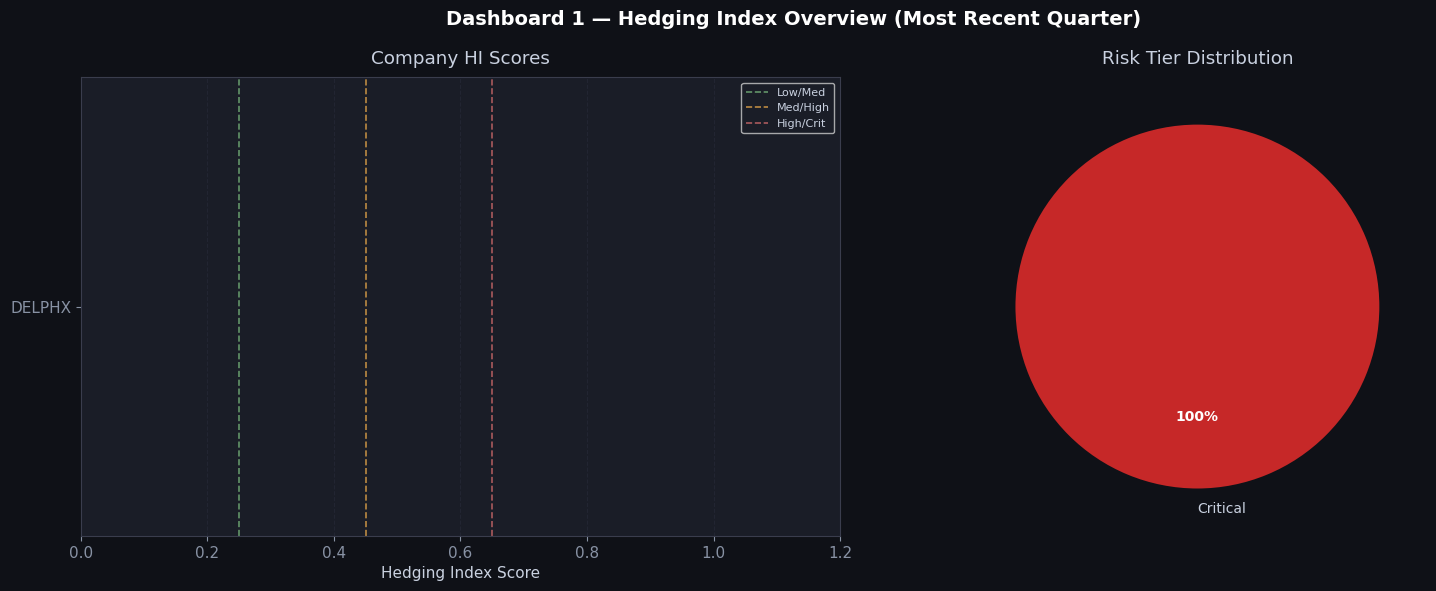

Dashboard 1 saved - Pie chart & Horizontal bar graph


In [ ]:
# Dashboard 1: HI Overview (Latest Quarter)

latest = (df.sort_values('quarter')
            .groupby('ticker', as_index=False)
            .last()
            .sort_values('hedging_index', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Dashboard 1 — Hedging Index Overview (Most Recent Quarter)',
             color='white', fontsize=14, fontweight='bold')

# Bar chart
ax = axes[0]
bar_colors = [RISK_COLORS[r] for r in latest['risk_level']]
bars = ax.barh(latest['ticker'], latest['hedging_index'],
               color=bar_colors, edgecolor='none', height=0.6)
for bar, val, risk in zip(bars, latest['hedging_index'], latest['risk_level']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}  [{risk}]', va='center',
            color=RISK_COLORS[risk], fontsize=9.5)
for thresh, col, lbl in [(THRESH_LOW,'#81c784','Low/Med'),
                          (THRESH_MED,'#ffb74d','Med/High'),
                          (THRESH_HIGH,'#e57373','High/Crit')]:
    ax.axvline(thresh, color=col, linewidth=1.2, linestyle='--', alpha=0.7, label=lbl)
ax.set_xlabel('Hedging Index Score')
ax.set_title('Company HI Scores', color='#c9d1e0', pad=10)
ax.set_xlim(0, 1.2)
ax.legend(fontsize=8)
ax.grid(axis='x')

# Pie chart
ax2 = axes[1]
risk_counts = latest['risk_level'].value_counts()
pie_colors  = [RISK_COLORS[r] for r in risk_counts.index]
wedges, texts, autotexts = ax2.pie(
    risk_counts.values, labels=risk_counts.index, colors=pie_colors,
    autopct='%1.0f%%', startangle=90,
    textprops={'color':'#c9d1e0', 'fontsize':10},
    wedgeprops={'edgecolor':'#0f1117', 'linewidth':2})
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold')
ax2.set_title('Risk Tier Distribution', color='#c9d1e0', pad=10)

plt.tight_layout()
plt.savefig('dashboard1_overview.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Dashboard 1 saved - Pie chart & Horizontal bar graph')

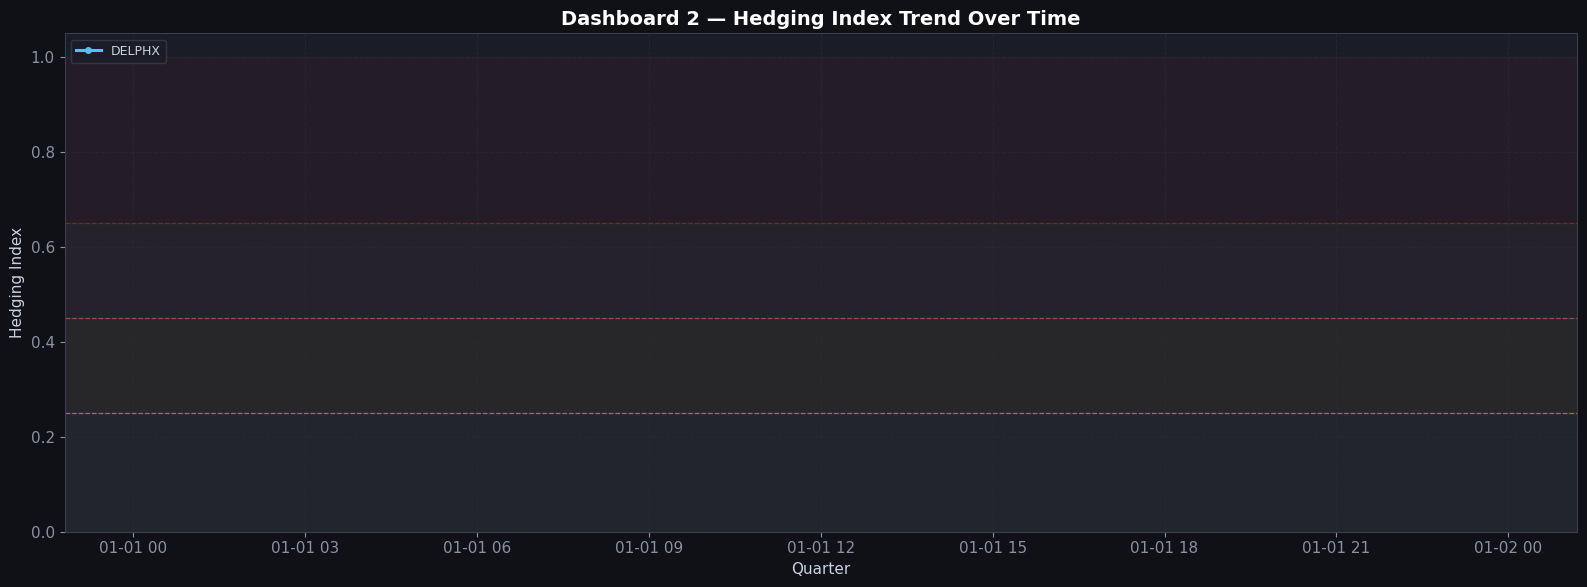

Dashboard 2 saved - Trend Lines graph


In [ ]:
# Dashboard 2: Temporal Trend Lines

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

tickers = df['ticker'].unique()
styles  = {}
if 'profile' in df.columns:
    styles = {'healthy':'solid', 'distressed':'dashed', 'failed':'dotted', 'real':'solid'}

for i, ticker in enumerate(tickers):
    sub = df[df['ticker'] == ticker].sort_values('quarter')
    profile  = sub['profile'].iloc[0] if 'profile' in df.columns else 'real'
    linestyle = styles.get(profile, 'solid')
    label     = f"{ticker} ({profile.capitalize()})" if profile != 'real' else ticker
    ax.plot(sub['quarter'], sub['hedging_index'],
            label=label, color=PALETTE[i % len(PALETTE)],
            linestyle=linestyle, linewidth=2.2,
            marker='o', markersize=4)

# Risk bands
for y0, y1, col in [(0, THRESH_LOW,'#81c784'),
                     (THRESH_LOW, THRESH_MED,'#ffb74d'),
                     (THRESH_MED, THRESH_HIGH,'#e57373'),
                     (THRESH_HIGH, 1.0,'#c62828')]:
    ax.axhspan(y0, y1, alpha=0.06, color=col)
for thresh, lbl, col in [(THRESH_LOW,'Medium','#ffb74d'),
                          (THRESH_MED,'High','#e57373'),
                          (THRESH_HIGH,'Critical','#c62828')]:
    ax.axhline(thresh, color=col, linewidth=0.9, linestyle='--', alpha=0.5)

ax.set_title('Dashboard 2 — Hedging Index Trend Over Time',
             color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Hedging Index')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=9, ncol=2,
          facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='#c9d1e0')
ax.grid(True)

plt.tight_layout()
plt.savefig('dashboard2_trends.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Dashboard 2 saved - Trend Lines graph')

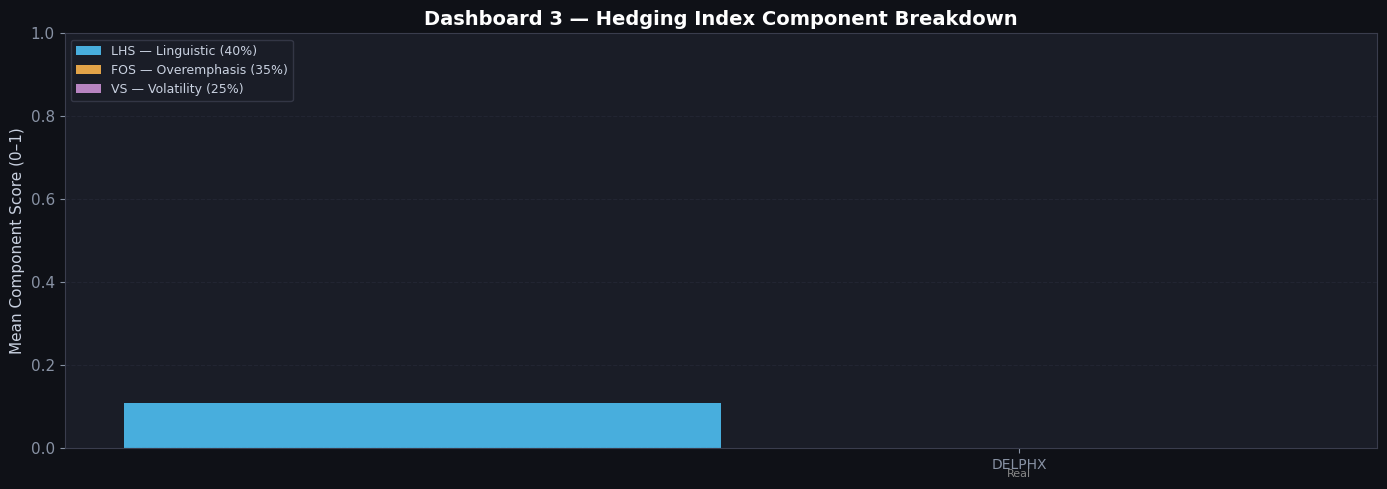

Dashboard 3 saved - Component breakdown bar graph


In [ ]:
# Dashboard 3: Component Breakdown

comp_mean = (df.groupby('ticker')[['lhs','fos','vs']]
               .mean()
               .reindex(latest.sort_values('hedging_index',
                        ascending=False)['ticker']))

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

x = np.arange(len(comp_mean))
w = 0.25
comp_colors = ['#4fc3f7', '#ffb74d', '#ce93d8']
comp_labels = ['LHS — Linguistic (40%)', 'FOS — Overemphasis (35%)',
               'VS — Volatility (25%)']

for i, (col, color, lbl) in enumerate(zip(['lhs','fos','vs'],
                                           comp_colors, comp_labels)):
    ax.bar(x + i*w, comp_mean[col], width=w, label=lbl,
           color=color, alpha=0.88, edgecolor='none')

ax.set_xticks(x + w)
ax.set_xticklabels(comp_mean.index, fontsize=10)
ax.set_ylabel('Mean Component Score (0–1)')
ax.set_ylim(0, 1.0)
ax.set_title('Dashboard 3 — Hedging Index Component Breakdown',
             color='white', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, facecolor='#1a1d27',
          edgecolor='#3a3d4d', labelcolor='#c9d1e0')
ax.grid(axis='y')

# Profile labels below tickers
if 'profile' in df.columns:
    profile_map = df.groupby('ticker')['profile'].first()
    for xi, ticker in enumerate(comp_mean.index):
        p = profile_map.get(ticker, '')
        c = PROFILE_COLOR.get(p, '#888')
        ax.text(xi + w, -0.07, p.capitalize(),
                ha='center', color=c, fontsize=8)

plt.tight_layout()
plt.savefig('dashboard3_components.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Dashboard 3 saved - Component breakdown bar graph')

In [ ]:
# Dashboard 4: Risk Heatmap

if df['quarter'].nunique() > 1:
    pivot = df.pivot_table(index='ticker', columns='quarter',
                           values='hedging_index')
    pivot.columns = [str(c.date()) for c in pivot.columns]
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(16, 4))
    fig.patch.set_facecolor('#0f1117')

    cmap = sns.blend_palette(['#1a4a1a','#81c784','#ffb74d',
                               '#e57373','#c62828'], as_cmap=True)
    sns.heatmap(pivot, ax=ax, cmap=cmap, vmin=0, vmax=0.9,
                annot=True, fmt='.2f',
                annot_kws={'size':8.5,'color':'white'},
                linewidths=1.0, linecolor='#0f1117',
                cbar_kws={'label':'Hedging Index'})

    ax.set_title('Dashboard 4 — Hedging Index Heatmap (All Companies × Quarters)',
                 color='white', fontsize=13, fontweight='bold')
    ax.set_xlabel('Quarter'); ax.set_ylabel('Ticker')
    ax.tick_params(axis='x', rotation=35)
    ax.set_yticklabels(pivot.index, rotation=0)

    plt.tight_layout()
    plt.savefig('dashboard4_heatmap.png', dpi=150,
                bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print('Dashboard 4 saved - Heatmap')
else:
    print('ℹ Dashboard 4 skipped — requires multiple quarters of data')
    print('  (SEDAR+ mode with a single filing will skip this panel)')

ℹ Dashboard 4 skipped — requires multiple quarters of data
  (SEDAR+ mode with a single filing will skip this panel)


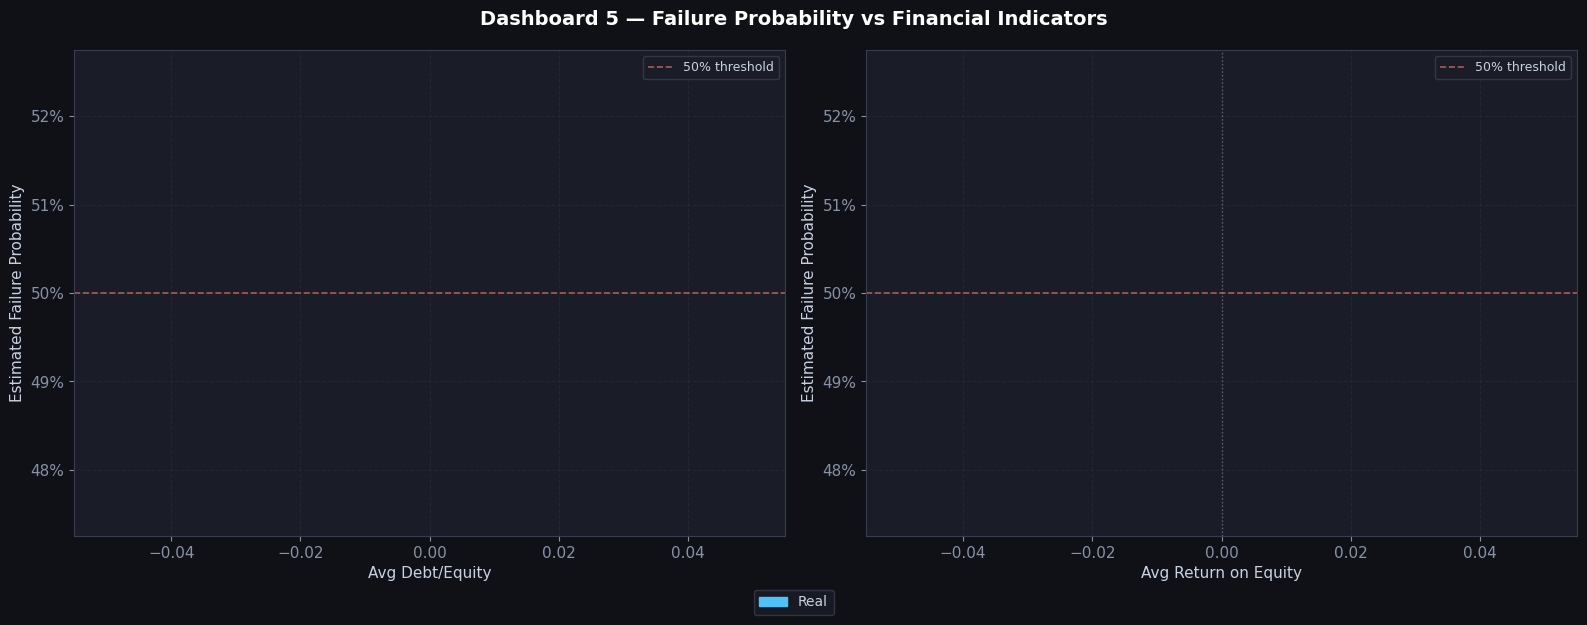

Dashboard 5 saved - Scatter plot


In [ ]:
# Dashboard 5: Failure Probability Scatter

def failure_probability(hi):
    return round(1 / (1 + np.exp(-SIGMOID_K * (hi - SIGMOID_THETA))), 4)

# Trailing average per company
last_q   = df['quarter'].nlargest(4).unique()
recent   = df[df['quarter'].isin(last_q)]
risk_sum = recent.groupby('ticker').agg(
    name        = ('name',           'first'),
    profile     = ('profile',        'first'),
    avg_hi      = ('hedging_index',  'mean'),
    avg_de      = ('debt_equity',    'mean'),
    avg_roe     = ('roe',            'mean'),
).reset_index()
risk_sum['failure_prob'] = risk_sum['avg_hi'].apply(failure_probability)
risk_sum['risk_level']   = risk_sum['avg_hi'].apply(classify_risk)
risk_sum = risk_sum.sort_values('failure_prob', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Dashboard 5 — Failure Probability vs Financial Indicators',
             color='white', fontsize=14, fontweight='bold')

markers = {'healthy':'o','distressed':'s','failed':'^','real':'D'}

for ax_idx, (xcol, xlabel) in enumerate([('avg_de','Avg Debt/Equity'),
                                           ('avg_roe','Avg Return on Equity')]):
    ax = axes[ax_idx]
    for _, row in risk_sum.iterrows():
        p   = row['profile'] if 'profile' in row.index else 'real'
        col = PROFILE_COLOR.get(p, '#4fc3f7')
        mrk = markers.get(p, 'o')
        ax.scatter(row[xcol], row['failure_prob'],
                   color=col, marker=mrk, s=150, zorder=5,
                   edgecolors='white', linewidth=0.8)
        ax.annotate(row['ticker'],
                    (row[xcol], row['failure_prob']),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=9, color='#c9d1e0')
    ax.axhline(0.5, color='#e57373', linewidth=1.2,
               linestyle='--', alpha=0.7, label='50% threshold')
    if ax_idx == 1:
        ax.axvline(0, color='#8892a4', linewidth=1,
                   linestyle=':', alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Estimated Failure Probability')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.legend(fontsize=9, facecolor='#1a1d27',
              edgecolor='#3a3d4d', labelcolor='#c9d1e0')
    ax.grid(True)

# Profile legend
patches = [mpatches.Patch(color=PROFILE_COLOR.get(p,'#4fc3f7'),
                           label=p.capitalize())
           for p in risk_sum['profile'].unique()]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=10, facecolor='#1a1d27',
           edgecolor='#3a3d4d', labelcolor='#c9d1e0',
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('dashboard5_scatter.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Dashboard 5 saved - Scatter plot')

---
## Stage 8 - Sensitivity Analysis
To test the robustness of the Hedging Index metric to the weight variation.

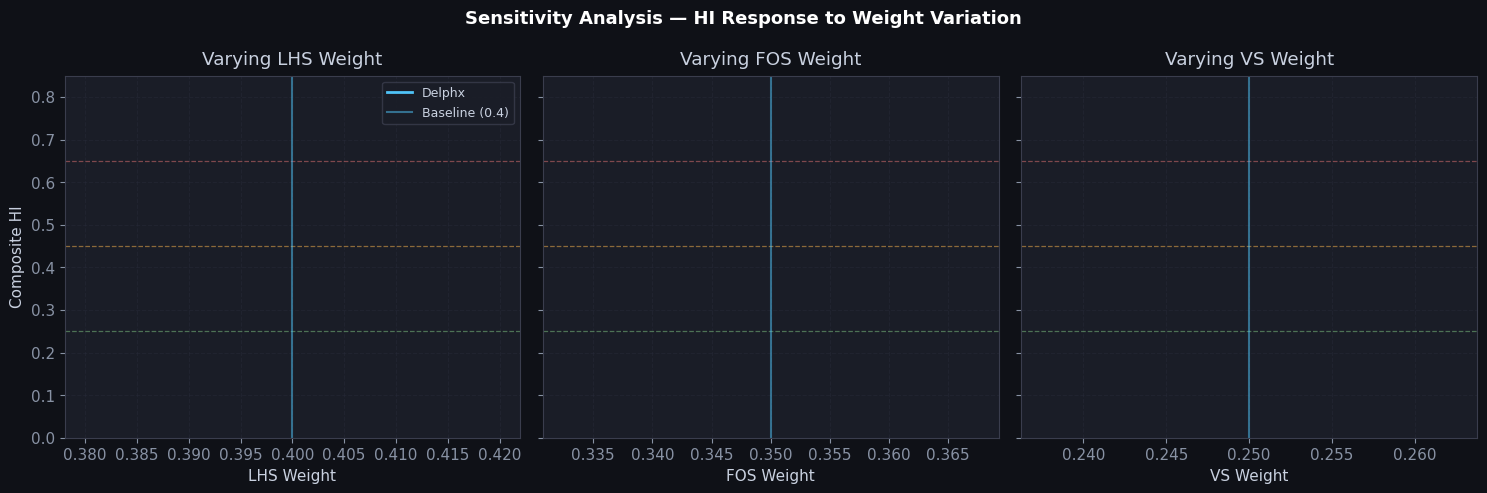

Sensitivity analysis complete


In [ ]:
# Sensitivity Analysis

weight_range = np.linspace(0.10, 0.60, 50)
base  = {'lhs': W_LHS, 'fos': W_FOS, 'vs': W_VS}
other = {'lhs':('fos','vs'), 'fos':('lhs','vs'), 'vs':('lhs','fos')}

# Mean component scores per profile/ticker
if 'profile' in df.columns and df['profile'].nunique() > 1:
    mean_scores = df.groupby('profile')[['lhs','fos','vs']].mean()
    group_col   = 'profile'
    color_map   = PROFILE_COLOR
else:
    mean_scores = df.groupby('ticker')[['lhs','fos','vs']].mean()
    group_col   = 'ticker'
    color_map   = {t: PALETTE[i % len(PALETTE)]
                   for i, t in enumerate(mean_scores.index)}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Sensitivity Analysis — HI Response to Weight Variation',
             color='white', fontsize=13, fontweight='bold')

for idx, varied in enumerate(['lhs', 'fos', 'vs']):
    ax   = axes[idx]
    o1, o2 = other[varied]

    for group, row in mean_scores.iterrows():
        hi_vals = []
        for w in weight_range:
            rem  = 1.0 - w
            w_o1 = base[o1] / (base[o1] + base[o2]) * rem
            w_o2 = base[o2] / (base[o1] + base[o2]) * rem
            hi   = w*row[varied] + w_o1*row[o1] + w_o2*row[o2]
            hi_vals.append(hi)
        ls = {'healthy':'solid','distressed':'dashed',
              'failed':'dotted'}.get(str(group), 'solid')
        ax.plot(weight_range, hi_vals,
                color=color_map.get(str(group), PALETTE[0]),
                linewidth=2.0, linestyle=ls,
                label=str(group).capitalize())

    for thresh, col in [(THRESH_LOW,'#81c784'),
                         (THRESH_MED,'#ffb74d'),
                         (THRESH_HIGH,'#e57373')]:
        ax.axhline(thresh, color=col, linewidth=0.9,
                   linestyle='--', alpha=0.5)
    ax.axvline(base[varied], color='#4fc3f7', linewidth=1.5,
               linestyle='-', alpha=0.5, label=f'Baseline ({base[varied]})')
    ax.set_xlabel(f'{varied.upper()} Weight')
    ax.set_ylabel('Composite HI' if idx == 0 else '')
    ax.set_title(f'Varying {varied.upper()} Weight',
                 color='#c9d1e0', pad=8)
    ax.set_ylim(0, 0.85)
    ax.grid(alpha=0.4)
    if idx == 0:
        ax.legend(fontsize=9, facecolor='#1a1d27',
                  edgecolor='#3a3d4d', labelcolor='#c9d1e0')

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Sensitivity analysis complete')

---
## Stage 9 - Full Risk Report
This section illustrates the final early warning output for all companies.

In [ ]:
# Full Risk Report

report = risk_sum.copy()
report['failure_pct'] = (report['failure_prob'] * 100).round(1)

TIER_EMOJI = {'Low':'🟢','Medium':'🟡','High':'🟠','Critical':'🔴'}

print('\n' + '='*72)
print(' EARLY WARNING RISK REPORT — CS-4982 Hedging Detection System')
print(f' Generated: {datetime.now().strftime("%B %d, %Y  %H:%M")}  |  Mode: {MODE.upper()}')
print('='*72)
print(f"{'Ticker':<8} {'Company':<24} {'Avg HI':>7} "
      f"{'Fail %':>8} {'Tier':>10}  {'Profile'}")
print('-'*72)

for _, row in report.iterrows():
    emoji = TIER_EMOJI.get(row['risk_level'], '')
    print(f"{row['ticker']:<8} {row['name']:<24} {row['avg_hi']:>7.3f} "
          f"{row['failure_pct']:>7.1f}%  "
          f"{emoji} {row['risk_level']:<8}  {row['profile']}")

print('='*72)
print(f"  Weights: LHS={W_LHS} · FOS={W_FOS} · VS={W_VS}")
print(f"  Sigmoid: k={SIGMOID_K} · θ={SIGMOID_THETA}")
print(f"  Note: Failure probability uses sigmoid mapping — "
      f"not a calibrated absolute probability.")
print('='*72)

# Save report to CSV (OPTIONAL)
report_out = report[['ticker','name','profile','avg_hi',
                      'failure_prob','risk_level','avg_de','avg_roe']].copy()
report_out.columns = ['Ticker','Company','Profile','Avg_HI',
                       'Failure_Prob','Risk_Tier','Avg_DE','Avg_ROE']
report_out.to_csv('hedging_risk_report.csv', index=False)
print('\n Report saved to: hedging_risk_report.csv')
print('  (Download from Files panel → right-click → Download)')


 EARLY WARNING RISK REPORT — CS-4982 Hedging Detection System
 Generated: April 10, 2026  23:17  |  Mode: SEDAR
Ticker   Company                   Avg HI   Fail %       Tier  Profile
------------------------------------------------------------------------
DELPHX   DELPHX                       nan     nan%  🔴 Critical  real
  Weights: LHS=0.4 · FOS=0.35 · VS=0.25
  Sigmoid: k=10 · θ=0.45
  Note: Failure probability uses sigmoid mapping — not a calibrated absolute probability.

 Report saved to: hedging_risk_report.csv
  (Download from Files panel → right-click → Download)


In [ ]:
# Export Full Dataset

export_cols = ['ticker','name','sector','profile','quarter',
               'pe_ratio','debt_equity','roe','current_ratio',
               'lhs','fos','vs','hedging_index','risk_level']

df[export_cols].to_csv('hedging_full_dataset.csv', index=False)

print('\n All outputs saved:')
outputs = [
    ('hedging_full_dataset.csv',    'Full dataset with all features'),
    ('hedging_risk_report.csv',     'Early warning risk report'),
    ('dashboard1_overview.png',     'HI overview + risk pie'),
    ('dashboard2_trends.png',       '12-quarter HI trend lines'),
    ('dashboard3_components.png',   'LHS / FOS / VS breakdown'),
    ('dashboard4_heatmap.png',      'HI heatmap (all companies × quarters)'),
    ('dashboard5_scatter.png',      'Failure prob vs. D/E and ROE'),
    ('sensitivity_analysis.png',    'Weight sensitivity analysis'),
]
for fname, desc in outputs:
    exists = '✓' if os.path.exists(fname) else '✗'
    print(f'  {exists}  {fname:<40} {desc}')

print('\n To download: Files panel (left sidebar) → right-click file → Download')


 All outputs saved:
  ✓  hedging_full_dataset.csv                 Full dataset with all features
  ✓  hedging_risk_report.csv                  Early warning risk report
  ✓  dashboard1_overview.png                  HI overview + risk pie
  ✓  dashboard2_trends.png                    12-quarter HI trend lines
  ✓  dashboard3_components.png                LHS / FOS / VS breakdown
  ✗  dashboard4_heatmap.png                   HI heatmap (all companies × quarters)
  ✓  dashboard5_scatter.png                   Failure prob vs. D/E and ROE
  ✓  sensitivity_analysis.png                 Weight sensitivity analysis

 To download: Files panel (left sidebar) → right-click file → Download


---
## 📌 Final Summary

This notebook has demonstrated the complete **CS-4982 Hedging Detection pipeline**:

| Stage | Description | Status |
|---|---|---|
| 1 | Installation & Imports | ✅ |
| 2 | Configuration (Synthetic / SEDAR+) | ✅ |
| 3 | Data Ingestion | ✅ |
| 4 | Preprocessing (cleaning, tokenisation) | ✅ |
| 5 | Feature Extraction (LHS, FOS, VS) | ✅ |
| 6 | Hedging Index Construction | ✅ |
| 7 | Visualisation Dashboard (5 panels) | ✅ |
| 8 | Sensitivity Analysis | ✅ |
| 9 | Early Warning Risk Report | ✅ |

### To run on real SEDAR+ data:
1. Visit **https://www.sedarplus.ca/**
2. Download MD&A filings as PDF
3. Upload to Colab via Files panel
4. Change `MODE = 'sedar'` in Stage 2
5. Run all cells

---
*CS-4982 Independent Research Project · University of New Brunswick · Darin Thomson · 2026*